170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1663s 10us/step


C:\Users\itzla\anaconda3\envs\power_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   Learning Rate  Accuracy
0         0.1000    0.1000
1         0.0100    0.3707
2         0.0010    0.4440
3         0.0001    0.4448


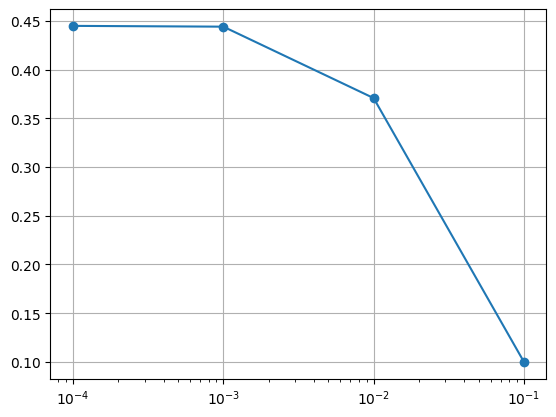

C:\Users\itzla\anaconda3\envs\power_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   Epochs  Accuracy
0       5    0.4537
1      10    0.4866
2      20    0.4798


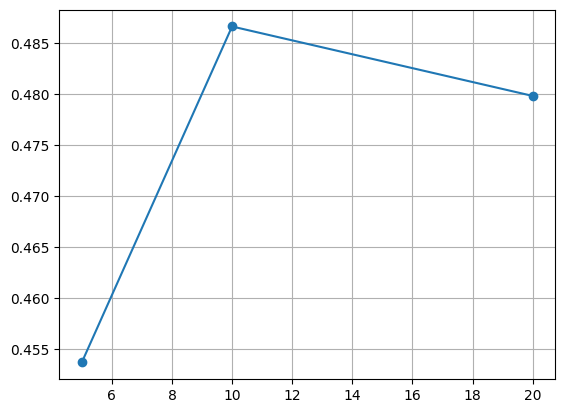

C:\Users\itzla\anaconda3\envs\power_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.3117 - loss: 1.9197 - val_accuracy: 0.3627 - val_loss: 1.8221
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.3836 - loss: 1.7267 - val_accuracy: 0.3840 - val_loss: 1.7291
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.4122 - loss: 1.6462 - val_accuracy: 0.4127 - val_loss: 1.6514
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.4347 - loss: 1.5865 - val_accuracy: 0.4169 - val_loss: 1.6261
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.4527 - loss: 1.5443 - val_accuracy: 0.4378 - val_loss: 1.5806
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.4638 - loss: 1.5031 - val_accuracy: 0.4403 - val_loss: 1.5861
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.4741 - loss: 1.4743 - val_accuracy: 0.4573 - val_loss: 1.5350
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.4873 - loss: 1.4483 - val_ac

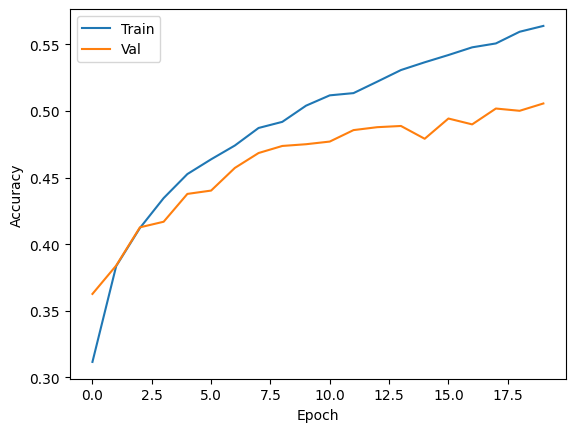

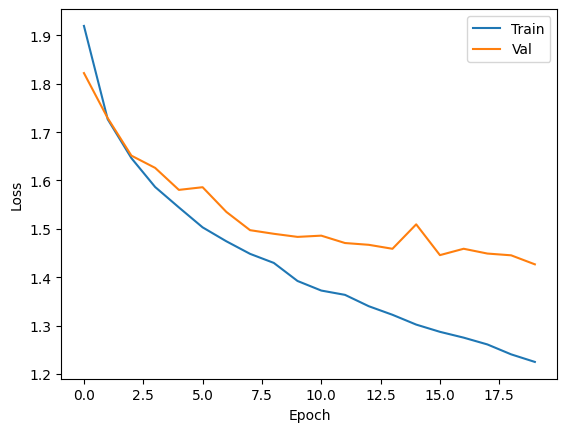

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5040 - loss: 1.4006
[1.400638222694397, 0.5040000081062317]


In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import pandas as pd

(x_train,y_train),(x_test,y_test)=tf.keras.datasets.cifar10.load_data()

y_train=y_train.flatten()
y_test=y_test.flatten()

x_train=x_train.reshape(-1,3072)/255.0
x_test=x_test.reshape(-1,3072)/255.0

def create_model(lr):
    m=Sequential([
        Dense(256,activation='relu',input_shape=(3072,)),
        Dense(128,activation='relu'),
        Dense(10,activation='softmax')
    ])

    m.compile(
        optimizer=Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return m

learning_rates=[0.1,0.01,0.001,0.0001]
results=[]

for lr in learning_rates:
    model=create_model(lr)
    model.fit(x_train,y_train,epochs=5,batch_size=128,verbose=0)

    loss,acc=model.evaluate(x_test,y_test,verbose=0)
    results.append([lr,acc])

df=pd.DataFrame(results,columns=['Learning Rate','Accuracy'])
print(df)

plt.plot(df['Learning Rate'],df['Accuracy'],marker='o')
plt.xscale('log')
plt.grid()
plt.show()

epochs_list=[5,10,20]
res=[]

for ep in epochs_list:
    model=create_model(0.001)

    h=model.fit(
        x_train,y_train,
        validation_split=0.2,
        epochs=ep,
        batch_size=128,
        verbose=0
    )

    loss,acc=model.evaluate(x_test,y_test,verbose=0)
    res.append([ep,acc])

edf=pd.DataFrame(res,columns=['Epochs','Accuracy'])
print(edf)

plt.plot(edf['Epochs'],edf['Accuracy'],marker='o')
plt.grid()
plt.show()

model=create_model(0.001)

history=model.fit(
    x_train,y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128
)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Val'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train','Val'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

print(model.evaluate(x_test,y_test))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


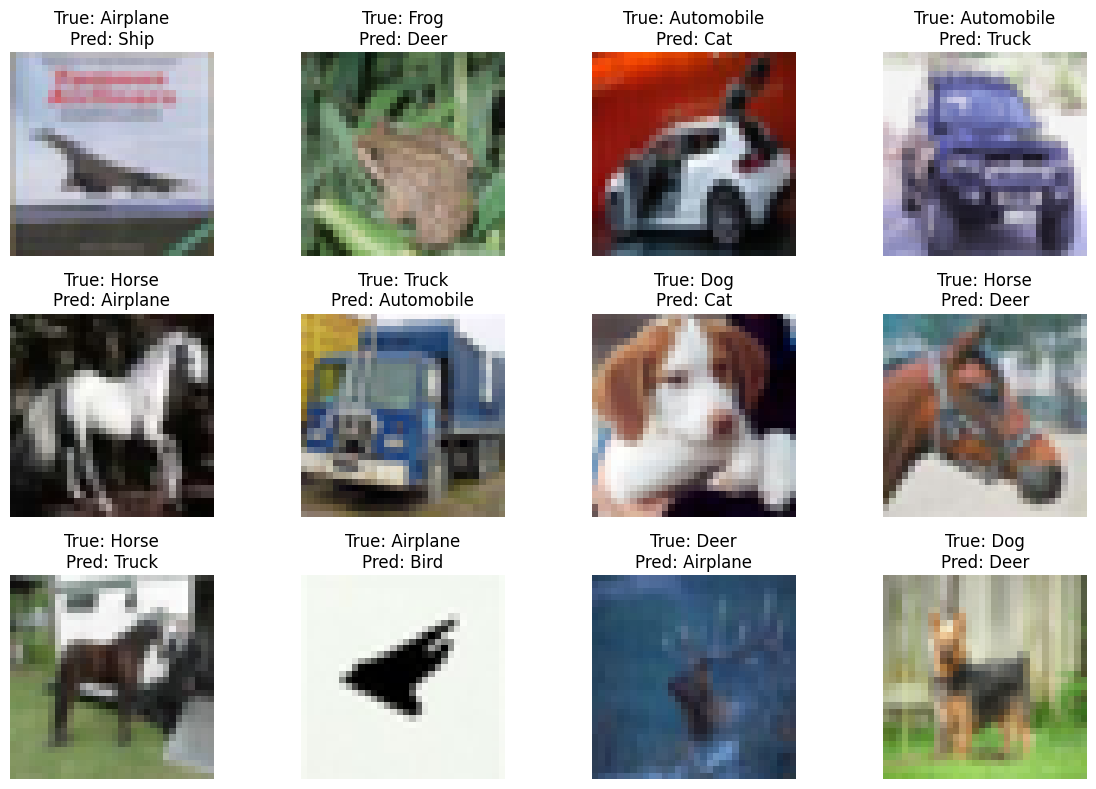

In [8]:
import numpy as np
class_names = ['Airplane','Automobile','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']
predictions = model.predict(x_test)

y_pred = np.argmax(predictions, axis=1)

y_test_flat = y_test.flatten()
images = x_test.reshape(-1,32,32,3)

wrong = np.where(y_pred != y_test)[0]

plt.figure(figsize=(12,8))

for i, idx in enumerate(wrong[:12]):
    plt.subplot(3,4,i+1)
    plt.imshow(images[idx])
    plt.title(
        f"True: {class_names[y_test[idx]]}\n"
        f"Pred: {class_names[y_pred[idx]]}"
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

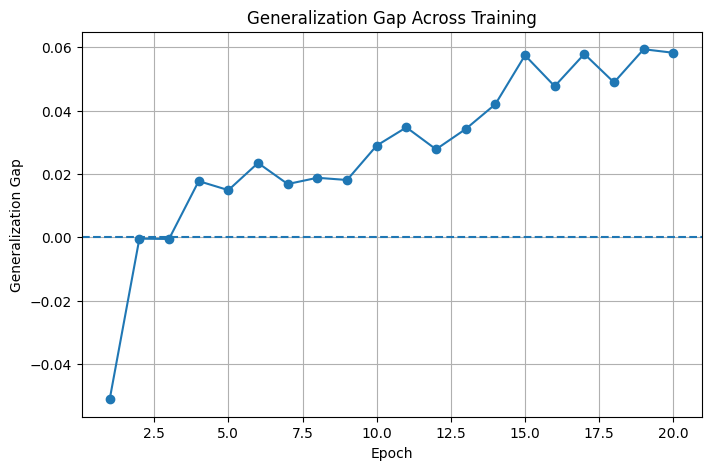

In [12]:
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

gap = np.array(train_acc) - np.array(val_acc)

plt.figure(figsize=(8,5))

plt.plot(range(1,21), gap, marker='o')

plt.axhline(y=0, linestyle='--')

plt.xlabel("Epoch")
plt.ylabel("Generalization Gap")
plt.title("Generalization Gap Across Training")

plt.grid()
plt.show()

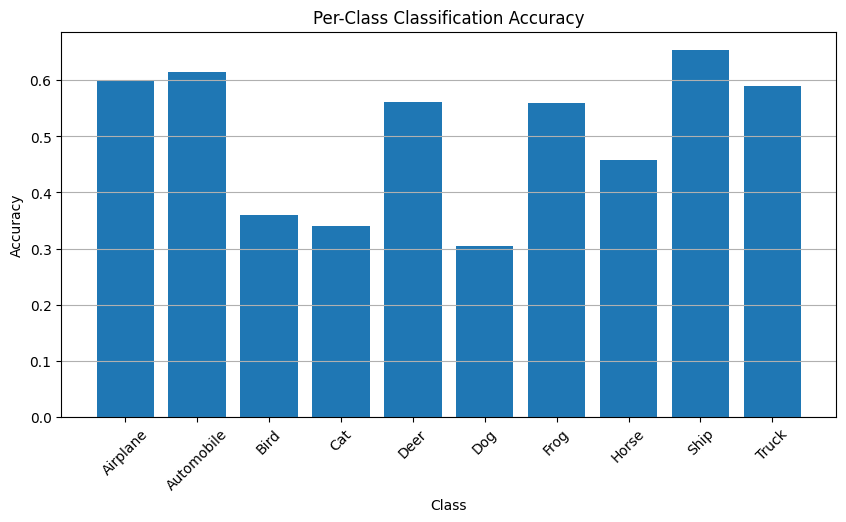

In [14]:
class_accuracy = []

for i in range(10):
    indices = y_test == i
    acc = np.mean(y_pred[indices] == y_test[indices])
    class_accuracy.append(acc)

plt.figure(figsize=(10,5))

plt.bar(class_names, class_accuracy)

plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.title("Per-Class Classification Accuracy")
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


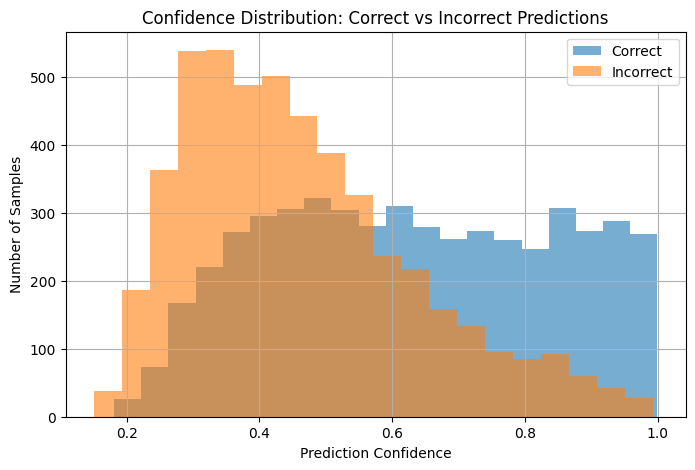

In [16]:
predictions = model.predict(x_test)

confidence = np.max(predictions, axis=1)

correct = y_pred == y_test

plt.figure(figsize=(8,5))

plt.hist(confidence[correct], bins=20, alpha=0.6, label='Correct')
plt.hist(confidence[~correct], bins=20, alpha=0.6, label='Incorrect')

plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Samples")
plt.title("Confidence Distribution: Correct vs Incorrect Predictions")
plt.legend()
plt.grid()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


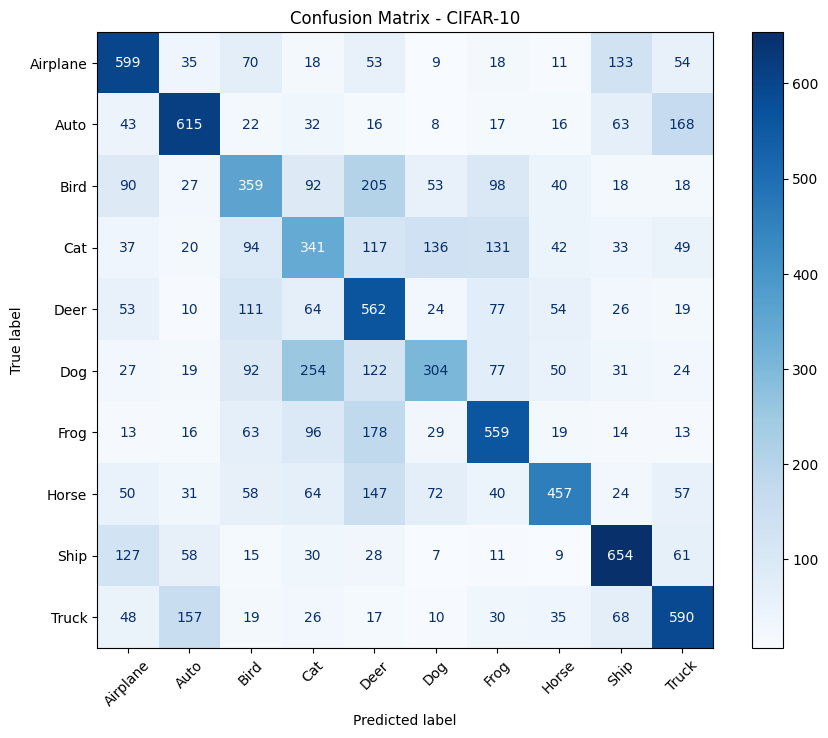

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_pred = np.argmax(model.predict(x_test), axis=1)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Airplane','Auto','Bird','Cat','Deer',
                    'Dog','Frog','Horse','Ship','Truck']
)

fig, ax = plt.subplots(figsize=(10,8))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - CIFAR-10")
plt.show()

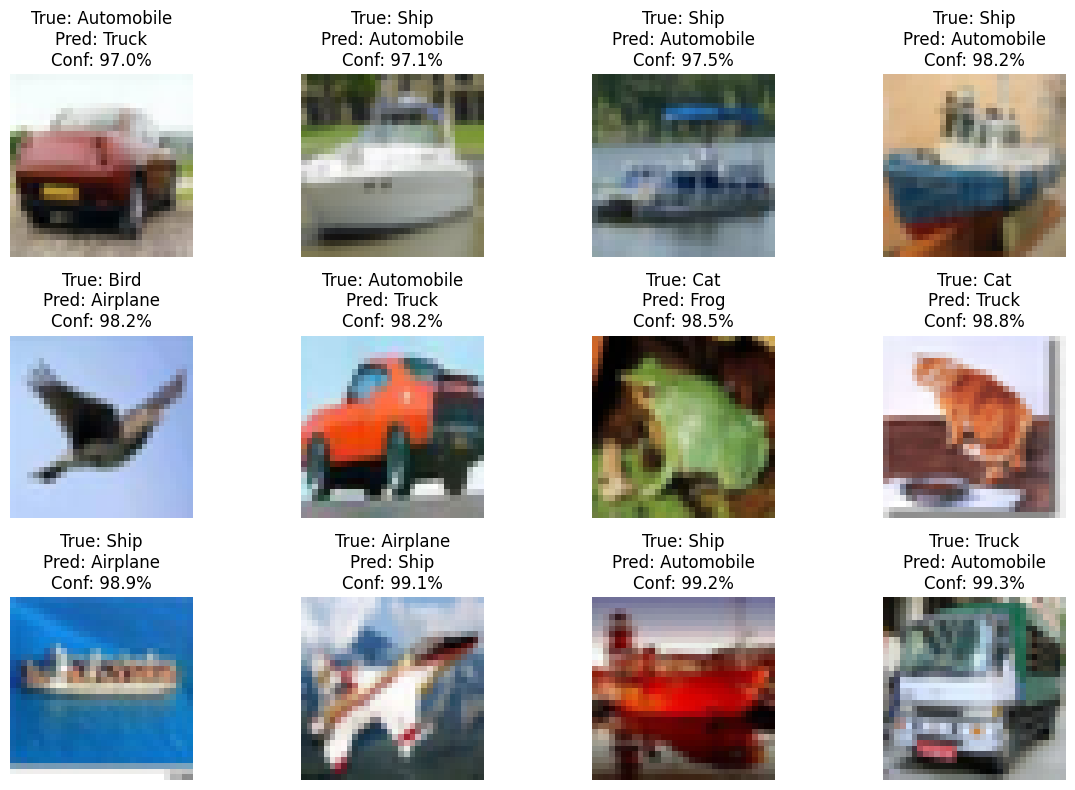

In [20]:
wrong_confidence = confidence[wrong]

top_wrong = wrong[np.argsort(wrong_confidence)[-12:]]

plt.figure(figsize=(12,8))

for i, idx in enumerate(top_wrong):

    plt.subplot(3,4,i+1)

    plt.imshow(images[idx])

    plt.title(
        f"True: {class_names[y_test[idx]]}\n"
        f"Pred: {class_names[y_pred[idx]]}\n"
        f"Conf: {confidence[idx]*100:.1f}%"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()